In [1]:
import pandas as pd
import numpy as np
import ast

# load the files 
careplans = pd.read_csv("/Users/saket/Desktop/BDA/careplans.csv")
symptoms = pd.read_csv("/Users/saket/Desktop/BDA/symptoms.csv")
patients = pd.read_csv("/Users/saket/Desktop/BDA/patients.csv")

In [2]:
print("careplans columns:", careplans.columns.tolist())
print("symptoms columns:", symptoms.columns.tolist())
print("patients columns:", patients.columns.tolist())

careplans columns: ['Id', 'START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']
symptoms columns: ['PATIENT', 'GENDER', 'RACE', 'ETHNICITY', 'AGE_BEGIN', 'AGE_END', 'PATHOLOGY', 'NUM_SYMPTOMS', 'SYMPTOMS']
patients columns: ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']


In [3]:
# clean the IDs and ensure they match across datasets
patients["Id"] = patients["Id"].astype(str).str.strip()
symptoms["PATIENT"] = symptoms["PATIENT"].astype(str).str.strip()
careplans["PATIENT"] = careplans["PATIENT"].astype(str).str.strip()

In [4]:
valid_ids = set(patients["Id"])

In [5]:
symptoms = symptoms[symptoms["PATIENT"].isin(valid_ids)].copy()
careplans = careplans[careplans["PATIENT"].isin(valid_ids)].copy()

In [6]:
print("\nExpected patients:", len(valid_ids))
print("Unique patients in symptoms:", symptoms["PATIENT"].nunique())
print("Unique patients in careplans:", careplans["PATIENT"].nunique())


Expected patients: 125
Unique patients in symptoms: 125
Unique patients in careplans: 119


In [7]:
# sanity checks
print("SANITY CHECKS")
print("Duplicate rows in symptoms:", symptoms.duplicated().sum())
print("Duplicate rows in careplans:", careplans.duplicated().sum())
print("Duplicate IDs in patients:", patients["Id"].duplicated().sum())

SANITY CHECKS
Duplicate rows in symptoms: 5179
Duplicate rows in careplans: 0
Duplicate IDs in patients: 0


In [8]:
print("\nMissing values in symptoms:")
print(symptoms.isna().sum())


Missing values in symptoms:
PATIENT             0
GENDER              0
RACE                0
ETHNICITY           0
AGE_BEGIN           0
AGE_END         16607
PATHOLOGY           0
NUM_SYMPTOMS        0
SYMPTOMS        24957
dtype: int64


In [9]:
print("\nMissing values in careplans:")
print(careplans.isna().sum())



Missing values in careplans:
Id                     0
START                  0
STOP                 238
PATIENT                0
ENCOUNTER              0
CODE                   0
DESCRIPTION            0
REASONCODE           199
REASONDESCRIPTION    199
dtype: int64


In [10]:
symptom_ids = set(symptoms["PATIENT"])
careplan_ids = set(careplans["PATIENT"])

print("\nPatients missing careplans:", len(symptom_ids - careplan_ids))
print("Patients missing symptoms:", len(careplan_ids - symptom_ids))


Patients missing careplans: 6
Patients missing symptoms: 0


In [11]:
# drop exact duplicate rows in symptoms
symptoms = symptoms.drop_duplicates().copy()

In [12]:
# clean text fields/strip them 
symptoms["PATHOLOGY"] = symptoms["PATHOLOGY"].astype(str).str.strip().str.lower()
symptoms["SYMPTOMS"] = symptoms["SYMPTOMS"].astype(str).str.strip()
careplans["DESCRIPTION"] = careplans["DESCRIPTION"].astype(str).str.strip().str.lower()

In [13]:
# parse the SYMPTOMS field into a list of symptoms
def parse_symptom_list(x):
    if pd.isna(x):
        return []

    x = str(x).strip()

    if x == "" or x.lower() == "nan":
        return []

    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [str(item).strip().lower() for item in parsed if str(item).strip() != ""]
    except:
        pass

    if ";" in x:
        parts = x.split(";")
    elif "," in x:
        parts = x.split(",")
    else:
        parts = [x]

    return [p.strip().lower() for p in parts if p.strip() != ""]

symptoms["SYMPTOM_LIST"] = symptoms["SYMPTOMS"].apply(parse_symptom_list)

In [14]:
# aggregate to one row per patient, taking first value for demographics and max for NUM_SYMPTOMS
patient_base = symptoms.groupby("PATIENT").agg({
    "GENDER": "first",
    "RACE": "first",
    "ETHNICITY": "first",
    "AGE_BEGIN": "first",
    "AGE_END": "first",
    "PATHOLOGY": "first",
    "NUM_SYMPTOMS": "max"
})

symptom_lists = symptoms.groupby("PATIENT")["SYMPTOM_LIST"].sum()
symptom_lists = symptom_lists.apply(lambda x: sorted(list(set(x))))
patient_base = patient_base.join(symptom_lists)

In [15]:
# create binary features for each unique symptom
all_symptoms = sorted(
    set(symptom for sublist in patient_base["SYMPTOM_LIST"] for symptom in sublist)
)

for symptom in all_symptoms:
    patient_base[f"SYMPTOM__{symptom}"] = patient_base["SYMPTOM_LIST"].apply(
        lambda x: int(symptom in x)
    )

patient_base["NUM_SYMPTOMS_COMPUTED"] = patient_base["SYMPTOM_LIST"].apply(len)

print("\nTotal unique symptom features:", len(all_symptoms))

/var/folders/sn/767wn_8x0wnc8t69b5wxj3n80000gn/T/ipykernel_11445/2137849586.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  patient_base[f"SYMPTOM__{symptom}"] = patient_base["SYMPTOM_LIST"].apply(
/var/folders/sn/767wn_8x0wnc8t69b5wxj3n80000gn/T/ipykernel_11445/2137849586.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  patient_base[f"SYMPTOM__{symptom}"] = patient_base["SYMPTOM_LIST"].apply(
/var/folders/sn/767wn_8x0wnc8t69b5wxj3n80000gn/T/ipykernel_11445/2137849586.py:7: PerformanceWarning: DataFrame is highly fragment


Total unique symptom features: 1558


/var/folders/sn/767wn_8x0wnc8t69b5wxj3n80000gn/T/ipykernel_11445/2137849586.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  patient_base[f"SYMPTOM__{symptom}"] = patient_base["SYMPTOM_LIST"].apply(
/var/folders/sn/767wn_8x0wnc8t69b5wxj3n80000gn/T/ipykernel_11445/2137849586.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  patient_base[f"SYMPTOM__{symptom}"] = patient_base["SYMPTOM_LIST"].apply(
/var/folders/sn/767wn_8x0wnc8t69b5wxj3n80000gn/T/ipykernel_11445/2137849586.py:7: PerformanceWarning: DataFrame is highly fragment

In [16]:
# aggregate careplans to patient level
careplans = careplans[careplans["DESCRIPTION"] != ""].copy()

careplan_lists = (
    careplans.groupby("PATIENT")["DESCRIPTION"]
    .apply(lambda x: sorted(list(set(x))))
    .rename("CAREPLAN_LIST")
)

patient_base = patient_base.join(careplan_lists)
patient_base["CAREPLAN_LIST"] = patient_base["CAREPLAN_LIST"].apply(
    lambda x: x if isinstance(x, list) else []
)
patient_base["NUM_CAREPLANS"] = patient_base["CAREPLAN_LIST"].apply(len)

all_careplans = sorted(
    set(cp for sublist in patient_base["CAREPLAN_LIST"] for cp in sublist)
)

for cp in all_careplans:
    patient_base[f"CAREPLAN__{cp}"] = patient_base["CAREPLAN_LIST"].apply(
        lambda x: int(cp in x)
    )

print("Total unique careplan labels:", len(all_careplans))

Total unique careplan labels: 33


In [17]:
# handle missing values
meta = patient_base.copy()

numeric_fill_cols = ["AGE_BEGIN", "AGE_END", "NUM_SYMPTOMS", "NUM_SYMPTOMS_COMPUTED", "NUM_CAREPLANS"]
for col in numeric_fill_cols:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors="coerce").fillna(0)

meta["PATHOLOGY"] = meta["PATHOLOGY"].fillna("unknown")
meta["SYMPTOM_LIST"] = meta["SYMPTOM_LIST"].apply(lambda x: x if isinstance(x, list) else [])
meta["CAREPLAN_LIST"] = meta["CAREPLAN_LIST"].apply(lambda x: x if isinstance(x, list) else [])

In [18]:
# encode categorical variables
meta_encoded = pd.get_dummies(
    meta,
    columns=["GENDER", "RACE", "ETHNICITY"],
    dummy_na=True
)

In [19]:
#  normalize numerical features
scale_cols = [c for c in ["AGE_BEGIN", "AGE_END", "NUM_SYMPTOMS", "NUM_SYMPTOMS_COMPUTED", "NUM_CAREPLANS"] if c in meta_encoded.columns]

for col in scale_cols:
    col_min = meta_encoded[col].min()
    col_max = meta_encoded[col].max()
    if col_max > col_min:
        meta_encoded[col] = (meta_encoded[col] - col_min) / (col_max - col_min)
    else:
        meta_encoded[col] = 0


In [20]:
# final checks
print("\n=== FINAL CHECKS ===")
print("Final shape:", meta_encoded.shape)
print("Unique patients in final dataset:", meta_encoded.index.nunique())
print("Missing values in final dataset:", meta_encoded.isna().sum().sum())
print("Duplicate patient rows:", meta_encoded.index.duplicated().sum())


=== FINAL CHECKS ===
Final shape: (125, 1611)
Unique patients in final dataset: 125
Missing values in final dataset: 0
Duplicate patient rows: 0


In [26]:
# save outputs
meta.to_csv("/Users/saket/Desktop/BDA/meta_dataset_readable.csv", index=True)
meta_encoded.to_csv("/Users/saket/Desktop/BDA/meta_dataset_ml_ready.csv", index=True)

print("\nSaved files:")
print("../meta_dataset_readable.csv")
print("../meta_dataset_ml_ready.csv")

print("\nPreview:")
print(meta_encoded.head())



Saved files:
../meta_dataset_readable.csv
../meta_dataset_ml_ready.csv

Preview:
                                      AGE_BEGIN   AGE_END  \
PATIENT                                                     
02801d23-cfa8-b4d1-2083-43bed6bb944f   0.166667  0.166667   
05da26d7-17ff-fafa-df9f-edeedbfad6cd   0.371795  0.371795   
0b50ccf6-0800-5c83-687e-273021d0f923   0.115385  0.115385   
10382a5c-6121-1daa-db39-1d19bc3b3869   0.666667  0.666667   
10c77f09-bbea-f7e9-c00c-846235dc8327   0.051282  0.243590   

                                                               PATHOLOGY  \
PATIENT                                                                    
02801d23-cfa8-b4d1-2083-43bed6bb944f         acute bronchitis (disorder)   
05da26d7-17ff-fafa-df9f-edeedbfad6cd  acute viral pharyngitis (disorder)   
0b50ccf6-0800-5c83-687e-273021d0f923         acute bronchitis (disorder)   
10382a5c-6121-1daa-db39-1d19bc3b3869         acute bronchitis (disorder)   
10c77f09-bbea-f7e9-c00c-846235dc83

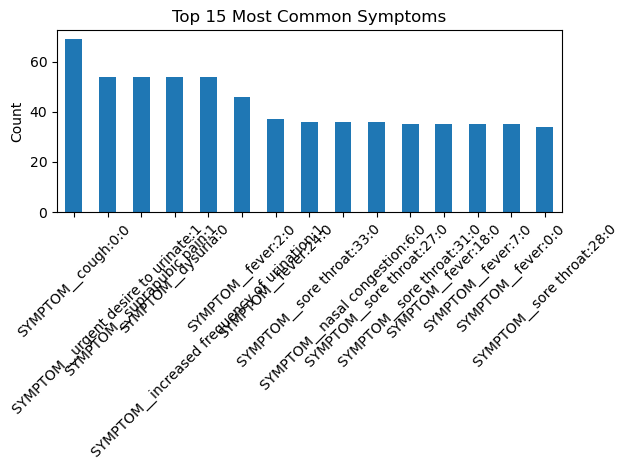

In [27]:

import matplotlib.pyplot as plt

symptom_cols = [c for c in meta_encoded.columns if c.startswith("SYMPTOM__")]

symptom_counts = meta_encoded[symptom_cols].sum().sort_values(ascending=False)

symptom_counts.head(15).plot(kind="bar")
plt.title("Top 15 Most Common Symptoms")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SVM

In [37]:
#Step 2: Define X and y
# X = symptom binary features + demographic dummies + normalized age/num_symptoms

meta_ml = pd.read_csv("/Users/saket/Desktop/BDA/meta_dataset_ml_ready.csv", index_col="PATIENT")
meta_readable = pd.read_csv("/Users/saket/Desktop/BDA/meta_dataset_readable.csv", index_col="PATIENT")

drop_cols = ["PATHOLOGY", "SYMPTOM_LIST", "CAREPLAN_LIST", 
             "AGE_BEGIN", "AGE_END",  # already normalized versions exist
             "NUM_CAREPLANS"]

X = meta_ml.drop(columns=[c for c in drop_cols if c in meta_ml.columns])
y = meta_readable["PATHOLOGY"]   # target: disease name

print("X shape:", X.shape)
print("Unique classes:", y.nunique())

X shape: (125, 1605)
Unique classes: 10


In [38]:
# Filter to pathologies with enough samples
from collections import Counter
class_counts = Counter(y)
valid_classes = {cls for cls, cnt in class_counts.items() if cnt >= 3}
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]
print(f"After filtering: {len(X)} patients, {y.nunique()} classes")

After filtering: 117 patients, 3 classes


In [39]:
#step 3:train/test & split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,         # 80/20 split
    random_state=42,
    stratify=y             # keeps class distribution balanced across splits
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (93, 1605) | Test size: (24, 1605)


In [40]:
#step 4: Train SVM
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers (SVM needs numeric y)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Start with RBF kernel — good default for non-linear medical data
svm_model = SVC(
    kernel="rbf",       # options: 'linear', 'rbf', 'poly'
    C=1.0,              # regularization — higher = less regularization
    gamma="scale",      # auto-scales based on feature variance
    class_weight="balanced", 
    decision_function_shape="ovr",   # one-vs-rest for multiclass
    random_state=42
)

svm_model.fit(X_train, y_train_enc)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [45]:
#step 6: hyperparameter tuning 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C":      [0.1, 1, 10, 100],
    "gamma":  ["scale", "auto"]   # only used by rbf/poly
}

grid_search = GridSearchCV(
    SVC(decision_function_shape="ovr", random_state=42),
    param_grid,
    cv=3,                   # 5-fold cross-validation
    scoring="accuracy",
    n_jobs=-1,              # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train_enc)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

# Refit with best model
best_svm = grid_search.best_estimator_

# Evaluate best model on test set
y_pred_best = best_svm.predict(X_test)
print("Best SVM Test Accuracy:", accuracy_score(y_test_enc, y_pred_best))
print(classification_report(
    le.inverse_transform(y_test_enc),
    le.inverse_transform(y_pred_best),
    zero_division=0
))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 0.9354838709677419
Best SVM Test Accuracy: 0.9583333333333334
                                    precision    recall  f1-score   support

       acute bronchitis (disorder)       0.96      1.00      0.98        22
acute viral pharyngitis (disorder)       0.00      0.00      0.00         1
 medication review due (situation)       1.00      1.00      1.00         1

                          accuracy                           0.96        24
                         macro avg       0.65      0.67      0.66        24
                      weighted avg       0.92      0.96      0.94        24



In [46]:
#Step 7: careplan recommendation logic 
# Build mapping: pathology → most common careplans
careplans_raw = pd.read_csv("/Users/saket/Desktop/BDA/careplans.csv")
symptoms_raw  = pd.read_csv("/Users/saket/Desktop/BDA/symptoms.csv")

# case mismatch resolved
symptoms_raw["PATHOLOGY"] = symptoms_raw["PATHOLOGY"].astype(str).str.strip().str.lower()
careplans_raw["DESCRIPTION"] = careplans_raw["DESCRIPTION"].astype(str).str.strip().str.lower()


# Get one pathology per patient (most frequent)
patient_pathology = (
    symptoms_raw.groupby("PATIENT")["PATHOLOGY"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"PATHOLOGY": "PRIMARY_PATHOLOGY"})
)

# Join careplans with patient's pathology
merged = careplans_raw.merge(patient_pathology, on="PATIENT", how="left")

# Build frequency map: pathology → ranked list of careplans
pathology_careplan_map = (
    merged.groupby(["PRIMARY_PATHOLOGY", "DESCRIPTION"])
    .size()
    .reset_index(name="count")
    .sort_values(["PRIMARY_PATHOLOGY", "count"], ascending=[True, False])
)

def get_recommended_careplans(pathology, top_n=3):
    recs = pathology_careplan_map[
        pathology_careplan_map["PRIMARY_PATHOLOGY"] == pathology
    ]["DESCRIPTION"].head(top_n).tolist()
    
    if not recs:
        # fallback: most common careplans overall
        recs = careplans_raw["DESCRIPTION"].value_counts().head(top_n).index.tolist()
    return recs

In [47]:
#step 8: full prediction
def predict_and_recommend(patient_features_row, top_n=3):
    """
    patient_features_row: a single row from X (as DataFrame)
    Returns predicted pathology + recommended careplans
    """
    pred_enc = best_svm.predict(patient_features_row)
    predicted_pathology = le.inverse_transform(pred_enc)[0]
    
    care_plans = get_recommended_careplans(predicted_pathology, top_n)
    
    print(f"Predicted condition: {predicted_pathology}")
    print(f"Recommended care plans:")
    for cp in care_plans:
        print(f"  - {cp}")
    
    return predicted_pathology, care_plans

In [48]:
# Example: predict and recommend on test set (for a test patient)
print("\n=== Sample Predictions ===")
for i in range(min(5, len(X_test))):
    sample = X_test.iloc[[i]]
    predict_and_recommend(sample)
    print()
    
    print(pathology_careplan_map.head(15))


=== Sample Predictions ===
Predicted condition: acute bronchitis (disorder)
Recommended care plans:
  - respiratory therapy (procedure)
  - diabetes self management plan (record artifact)
  - lifestyle education regarding hypertension (procedure)

                    PRIMARY_PATHOLOGY  \
24  medication review due (situation)   
7   medication review due (situation)   
16  medication review due (situation)   
25  medication review due (situation)   
20  medication review due (situation)   
10  medication review due (situation)   
4   medication review due (situation)   
26  medication review due (situation)   
13  medication review due (situation)   
14  medication review due (situation)   
32  medication review due (situation)   
15  medication review due (situation)   
9   medication review due (situation)   
22  medication review due (situation)   
30  medication review due (situation)   

                                          DESCRIPTION  count  
24                    respirato